In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [ ]:
import warnings
warnings.filterwarnings('ignore') # Ignore warnings for cleaner output

In [ ]:
# Load the dataset from the specified CSV file into a pandas DataFrame
df = pd.read_csv("/content/crop_recommendation.csv")

In [ ]:
# Display the shape of the DataFrame (number of rows, number of columns)
df.shape

(2200, 8)

In [ ]:
# Display the first 5 rows of the DataFrame to get an overview of the data
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
# Display the last 5 rows of the DataFrame
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [ ]:
# Display 5 random rows from the DataFrame
df.sample(5)

,N,P,K,temperature,humidity,ph,rainfall,label
1662,12,29,13,22.456169,91.527818,7.571254,118.006929,orange
2086,72,41,36,26.508387,86.842640,6.065898,152.980170,jute
1397,96,18,50,25.331045,84.305338,6.904242,41.532187,watermelon
1187,22,38,31,31.533564,53.060093,5.821106,98.570250,mango
1009,105,77,52,29.162266,76.161516,5.816622,100.007568,banana


In [ ]:
# Generate descriptive statistics of the DataFrame's numerical columns
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
# Print a concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
# Display the column names of the DataFrame
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [ ]:
# Check for missing values in each column and sum them up
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [ ]:
# Count the number of unique values in each column
df.nunique()

,0
N,137
P,117
K,73
temperature,2200
humidity,2200
ph,2200
rainfall,2200
label,22


In [ ]:
# Display all unique values in the 'label' column (crop types)
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [ ]:
# Count the occurrences of each unique value in the 'label' column
df['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [ ]:
# Create the feature matrix X by dropping the 'label' column
X = df.drop(columns='label')

In [ ]:
# Display the feature matrix X
X

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507
2196,99,15,27,27.417112,56.636362,6.086922,127.924610
2197,118,33,30,24.131797,67.225123,6.362608,173.322839
2198,117,32,34,26.272418,52.127394,6.758793,127.175293


In [ ]:
# Create the target vector y containing only the 'label' column
y = df['label']

In [ ]:
# Display the target vector y
y

,label
0,rice
1,rice
2,rice
3,rice
4,rice
...,...
2195,coffee
2196,coffee
2197,coffee
2198,coffee


In [ ]:
# Create a pivot table to summarize the mean of each feature grouped by 'label'
crop_summary = pd.pivot_table(df,index=['label'],aggfunc='mean')

In [ ]:
# Display the crop summary pivot table
crop_summary

,K,N,P,humidity,ph,rainfall,temperature
label,,,,,,,
apple,199.89,20.80,134.22,92.333383,5.929663,112.654779,22.630942
banana,50.05,100.23,82.01,80.358123,5.983893,104.626980,27.376798
blackgram,19.24,40.02,67.47,65.118426,7.133952,67.884151,29.973340
chickpea,79.92,40.09,67.79,16.860439,7.336957,80.058977,18.872847
coconut,30.59,21.98,16.93,94.844272,5.976562,175.686646,27.409892
coffee,29.94,101.20,28.74,58.869846,6.790308,158.066295,25.540477
cotton,19.56,117.77,46.24,79.843474,6.912675,80.398043,23.988958
grapes,200.11,23.18,132.53,81.875228,6.025937,69.611829,23.849575
jute,39.99,78.40,46.86,79.639864,6.732778,174.792798,24.958376


Nitrogen (N) Analysis:
Average Nitrogen Level: 50.551818181818184
Minimum Nitrogen Level: 0
Maximum Nitrogen Level: 140


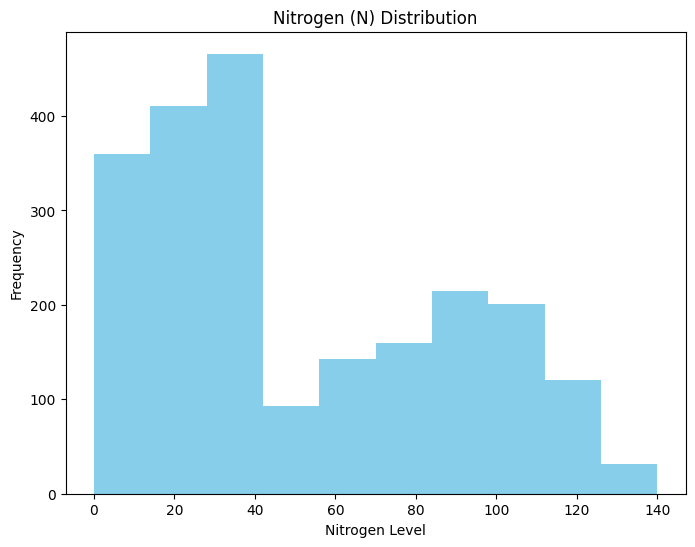

In [ ]:
# Analyze and visualize the distribution of Nitrogen (N)
print("Nitrogen (N) Analysis:")
print("Average Nitrogen Level:", df['N'].mean())
print("Minimum Nitrogen Level:", df['N'].min())
print("Maximum Nitrogen Level:", df['N'].max())
plt.figure(figsize=(8, 6))
plt.hist(df['N'], bins=10, color='skyblue')
plt.title('Nitrogen (N) Distribution')
plt.xlabel('Nitrogen Level')
plt.ylabel('Frequency')
plt.show()


Phosphorus (P) Analysis:
Average Phosphorus Level: 53.36272727272727
Minimum Phosphorus Level: 5
Maximum Phosphorus Level: 145


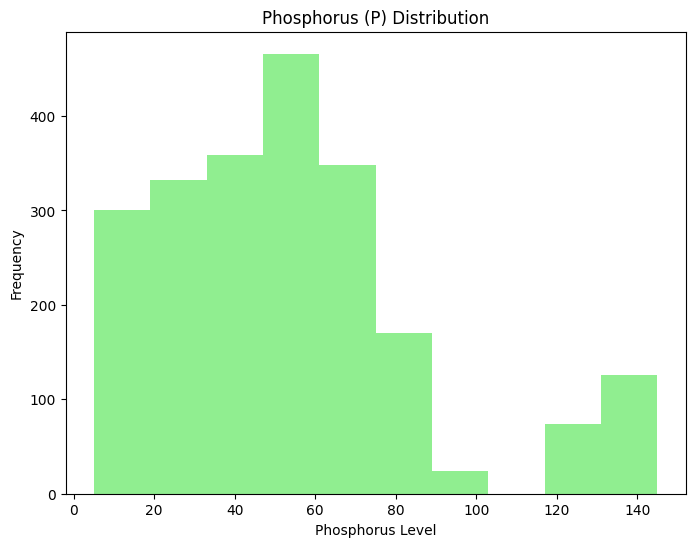

In [ ]:
# Analyze and visualize the distribution of Phosphorus (P)
print("\nPhosphorus (P) Analysis:")
print("Average Phosphorus Level:", df['P'].mean())
print("Minimum Phosphorus Level:", df['P'].min())
print("Maximum Phosphorus Level:", df['P'].max())
plt.figure(figsize=(8, 6))
plt.hist(df['P'], bins=10, color='lightgreen')
plt.title('Phosphorus (P) Distribution')
plt.xlabel('Phosphorus Level')
plt.ylabel('Frequency')
plt.show()


Potassium (K) Analysis:
Average Potassium Level: 48.14909090909091
Minimum Potassium Level: 5
Maximum Potassium Level: 205


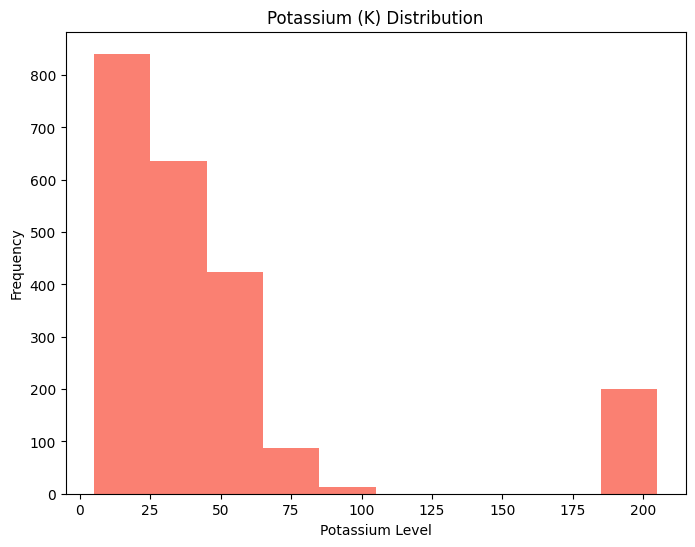

In [ ]:
# Analyze and visualize the distribution of Potassium (K)
print("\nPotassium (K) Analysis:")
print("Average Potassium Level:", df['K'].mean())
print("Minimum Potassium Level:", df['K'].min())
print("Maximum Potassium Level:", df['K'].max())
plt.figure(figsize=(8, 6))
plt.hist(df['K'], bins=10, color='salmon')
plt.title('Potassium (K) Distribution')
plt.xlabel('Potassium Level')
plt.ylabel('Frequency')
plt.show()


Temperature Analysis:
Average Temperature: 25.616243851779544
Minimum Temperature: 8.825674745
Maximum Temperature: 43.67549305


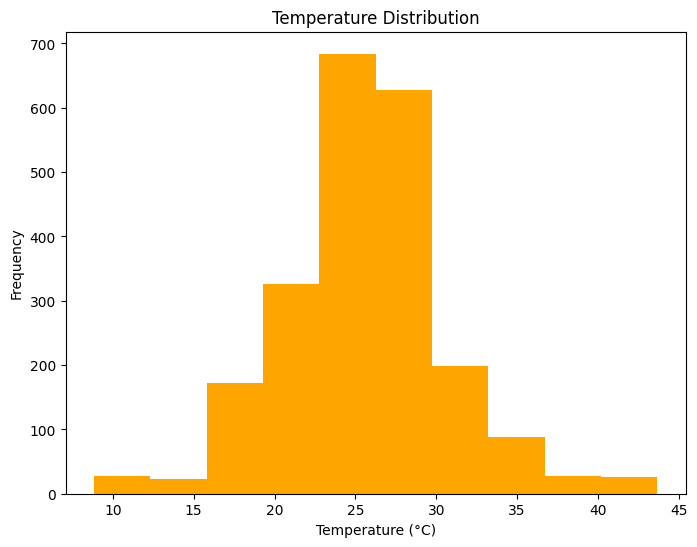

In [ ]:
# Analyze and visualize the distribution of Temperature
print("\nTemperature Analysis:")
print("Average Temperature:", df['temperature'].mean())
print("Minimum Temperature:", df['temperature'].min())
print("Maximum Temperature:", df['temperature'].max())
plt.figure(figsize=(8, 6))
plt.hist(df['temperature'], bins=10, color='orange')
plt.title('Temperature Distribution')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()


Humidity Analysis:
Average Humidity: 71.48177921778637
Minimum Humidity: 14.25803981
Maximum Humidity: 99.98187601


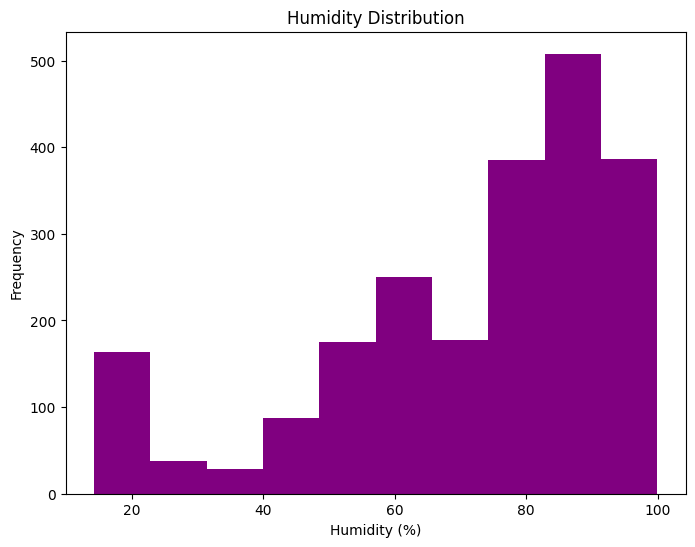

In [ ]:
# Analyze and visualize the distribution of Humidity
print("\nHumidity Analysis:")
print("Average Humidity:", df['humidity'].mean())
print("Minimum Humidity:", df['humidity'].min())
print("Maximum Humidity:", df['humidity'].max())
plt.figure(figsize=(8, 6))
plt.hist(df['humidity'], bins=10, color='purple')
plt.title('Humidity Distribution')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')
plt.show()


pH Analysis:
Average pH Level: 6.469480065256364
Minimum pH Level: 3.504752314
Maximum pH Level: 9.93509073


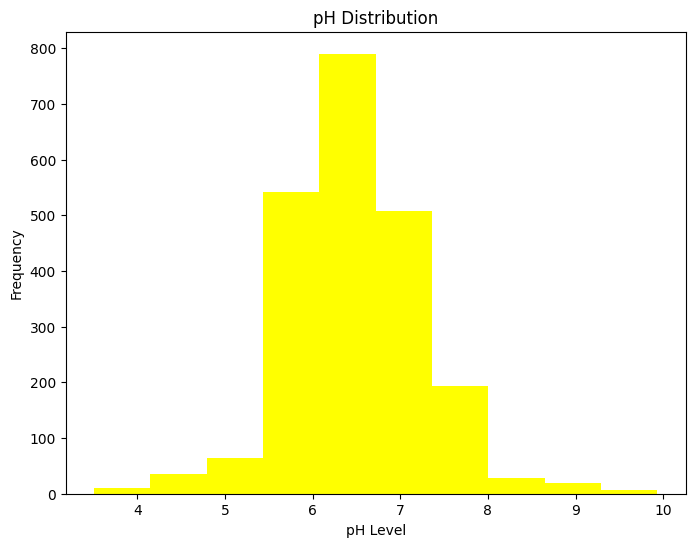

In [ ]:
# Analyze and visualize the distribution of pH
print("\npH Analysis:")
print("Average pH Level:", df['ph'].mean())
print("Minimum pH Level:", df['ph'].min())
print("Maximum pH Level:", df['ph'].max())
plt.figure(figsize=(8, 6))
plt.hist(df['ph'], bins=10, color='yellow')
plt.title('pH Distribution')
plt.xlabel('pH Level')
plt.ylabel('Frequency')
plt.show()


Rainfall Analysis:
Average Rainfall: 103.46365541576817
Minimum Rainfall: 20.21126747
Maximum Rainfall: 298.5601175


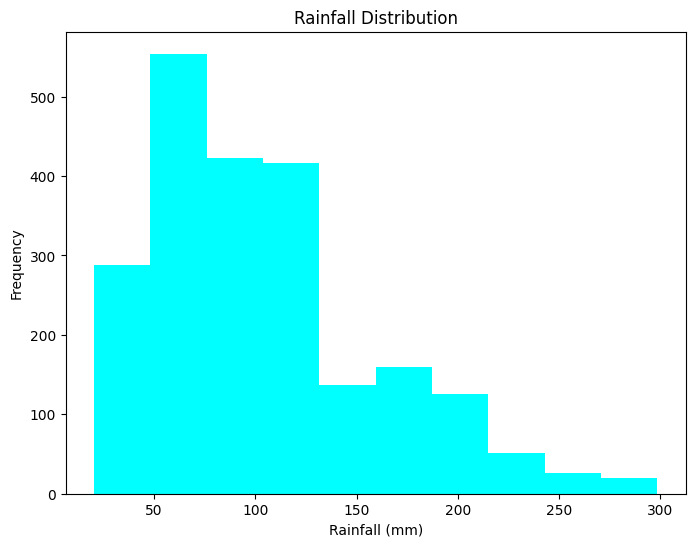

In [ ]:
# Analyze and visualize the distribution of Rainfall
print("\nRainfall Analysis:")
print("Average Rainfall:", df['rainfall'].mean())
print("Minimum Rainfall:", df['rainfall'].min())
print("Maximum Rainfall:", df['rainfall'].max())
plt.figure(figsize=(8, 6))
plt.hist(df['rainfall'], bins=10, color='cyan')
plt.title('Rainfall Distribution')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.show()

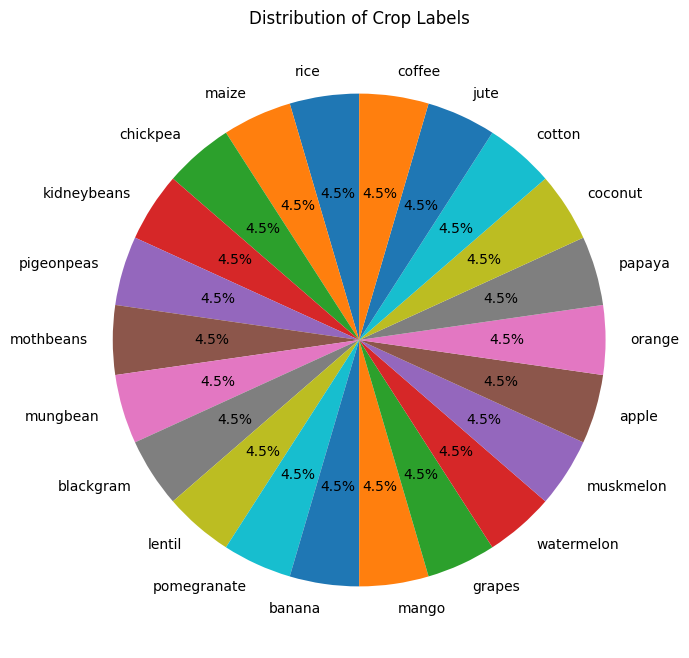

In [ ]:
import matplotlib.pyplot as plt
# Get the counts of each unique crop label
output_counts = df["label"].value_counts()
# Plot a pie chart to visualize the distribution of crop labels
plt.figure(figsize=(8,8))
plt.pie(output_counts.values, labels=output_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Crop Labels')
plt.show()

In [ ]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20,
                                                    shuffle = True, random_state = 0)

In [ ]:
X_train

,N,P,K,temperature,humidity,ph,rainfall
1567,27,120,200,21.452787,90.745319,6.110219,116.703658
2031,81,36,38,23.765547,87.983299,6.334838,150.316615
2073,90,59,35,24.251335,89.864541,7.098228,175.174211
1374,81,16,45,26.904357,86.254262,6.727468,59.759800
279,47,80,77,17.182484,16.428918,7.561108,72.850173
...,...,...,...,...,...,...,...
1033,102,71,48,28.654563,79.286937,5.695268,102.463378
1731,34,68,51,27.347349,94.177567,6.687088,40.351531
763,35,64,15,28.474423,63.536045,6.500145,69.527441
835,39,65,23,25.434598,69.126134,7.685959,41.026829


In [ ]:
X_test

,N,P,K,temperature,humidity,ph,rainfall
1320,105,14,50,26.214884,87.688398,6.419052,59.655908
1367,91,12,46,24.644585,85.499382,6.343943,48.312190
1291,14,121,203,9.724458,83.747656,6.158689,74.464111
264,52,73,79,17.257695,18.749440,7.840339,94.002872
728,32,66,17,34.946616,65.267740,7.162358,70.141514
...,...,...,...,...,...,...,...
446,32,70,20,20.893427,46.248565,6.208843,195.569787
1005,93,94,53,25.866324,84.423793,6.079179,114.535750
1919,117,56,15,25.992374,77.054355,7.368258,89.118821
708,27,64,21,32.842130,68.684015,7.543804,73.671662


In [ ]:
y_train

,label
1567,apple
2031,jute
2073,jute
1374,watermelon
279,chickpea
...,...
1033,banana
1731,papaya
763,blackgram
835,lentil


In [ ]:
y_test

,label
1320,watermelon
1367,watermelon
1291,grapes
264,chickpea
728,blackgram
...,...
446,pigeonpeas
1005,banana
1919,cotton
708,blackgram


In [ ]:
# Initialzing empty lists to append all model's name and corresponding name
acc = []
model = []

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
# Initialize the Logistic Regression classifier
classifier_lr = LogisticRegression(random_state = 0)

In [ ]:
# Train the Logistic Regression model using the training data
classifier_lr.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
# Make predictions on the test set using the trained Logistic Regression model
y_pred = classifier_lr.predict(X_test)

In [ ]:
# Calculate the accuracy score of the Logistic Regression model
accuracy = accuracy_score(y_pred, y_test)
acc.append(accuracy)
model.append('Logistic Regression')
print('Logistic Regression Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))

Logistic Regression Model accuracy score: 0.9682


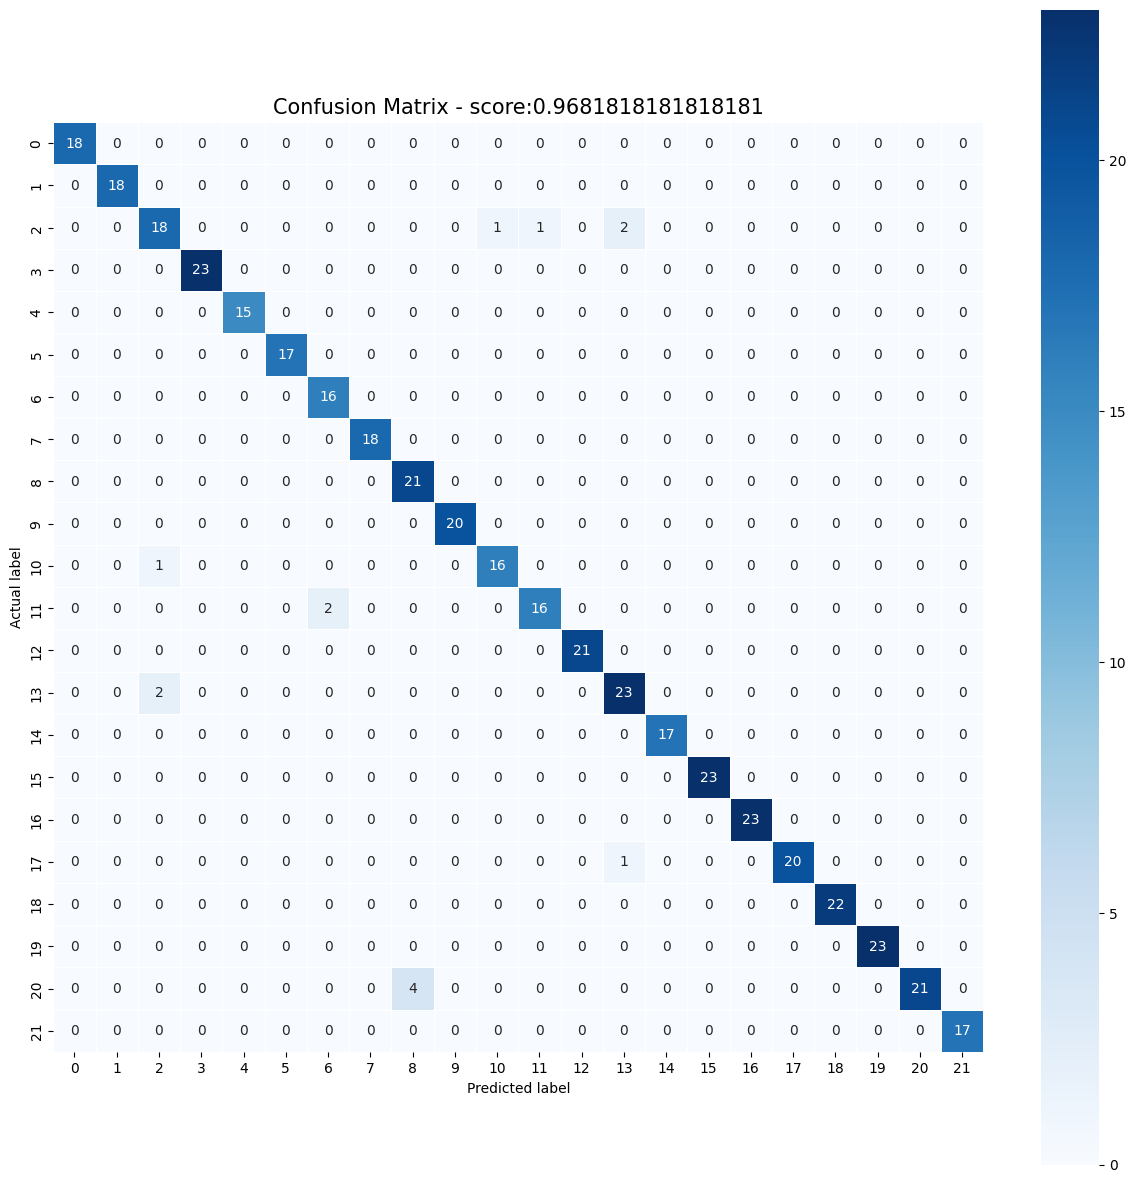

In [ ]:
# Generate the confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(15,15))

# Plot the confusion matrix using seaborn heatmap
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Confusion Matrix - score:'+str(accuracy_score(y_test,y_pred))
plt.title(all_sample_title, size = 15);
plt.show()

In [ ]:
# Print the classification report for Logistic Regression, showing precision, recall, f1-score, and support
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        18
   blackgram       0.86      0.82      0.84        22
    chickpea       1.00      1.00      1.00        23
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        17
      cotton       0.89      1.00      0.94        16
      grapes       1.00      1.00      1.00        18
        jute       0.84      1.00      0.91        21
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.94      0.94        17
       maize       0.94      0.89      0.91        18
       mango       1.00      1.00      1.00        21
   mothbeans       0.88      0.92      0.90        25
    mungbean       1.00      1.00      1.00        17
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00        23
      papaya       1.00    

## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Initialize the Decision Tree classifier with 'entropy' criterion
classifier= DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
# Train the Decision Tree model using the training data
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
# Make predictions on the test set using the trained Decision Tree model
y_pred=classifier.predict(X_test)

In [ ]:
# Calculate the accuracy score of the Decision Tree model
accuracy=accuracy_score(y_pred, y_test)
acc.append(accuracy)
model.append('Decision Tree')
print('Decision Tree Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))

Decision Tree Model accuracy score: 0.9909


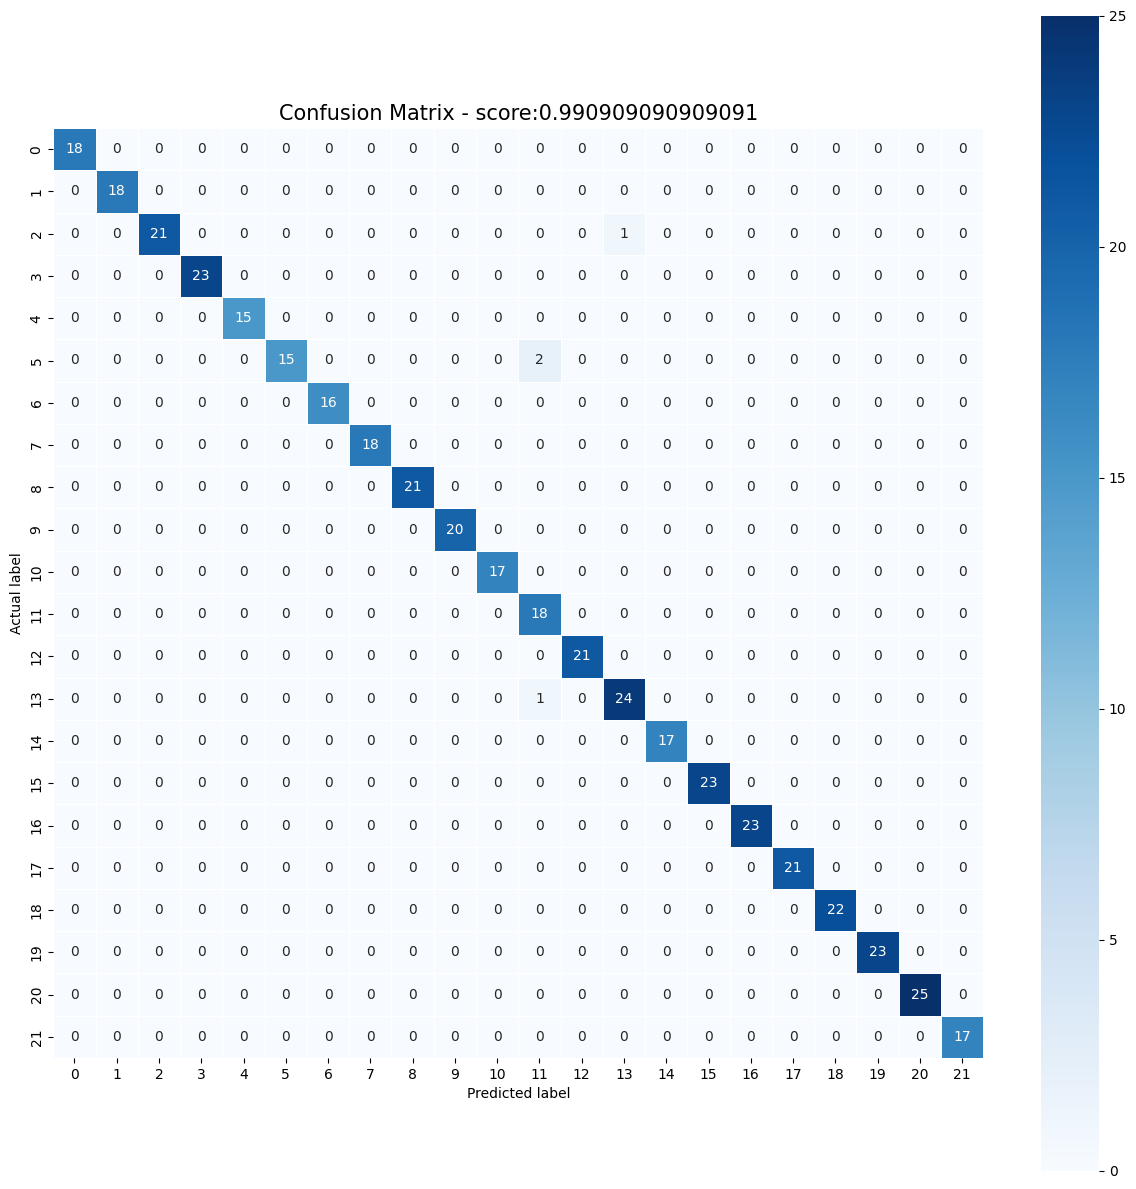

In [ ]:
# Generate the confusion matrix for Decision Tree
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(15,15))

# Plot the confusion matrix using seaborn heatmap
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Confusion Matrix - score:'+str(accuracy_score(y_test,y_pred))
plt.title(all_sample_title, size = 15);
plt.show()

In [ ]:
# Print the classification report for Decision Tree
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        18
   blackgram       1.00      0.95      0.98        22
    chickpea       1.00      1.00      1.00        23
     coconut       1.00      1.00      1.00        15
      coffee       1.00      0.88      0.94        17
      cotton       1.00      1.00      1.00        16
      grapes       1.00      1.00      1.00        18
        jute       1.00      1.00      1.00        21
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        17
       maize       0.86      1.00      0.92        18
       mango       1.00      1.00      1.00        21
   mothbeans       0.96      0.96      0.96        25
    mungbean       1.00      1.00      1.00        17
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00        23
      papaya       1.00    

## Random Forest


In [ ]:
# Initialize the Random Forest classifier with 10 estimators and 'entropy' criterion
classifier_rf= RandomForestClassifier(n_estimators= 10, criterion="entropy")

In [ ]:
# Train the Random Forest model using the training data
classifier_rf.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10)

In [ ]:
# Make predictions on the test set using the trained Random Forest model
y_pred= classifier_rf.predict(X_test)

In [ ]:
# Calculate the accuracy score of the Random Forest model
accuracy=accuracy_score(y_pred, y_test)
acc.append(accuracy)
model.append('Random Forest')
print('Random Forest Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))

Random Forest Model accuracy score: 0.9909


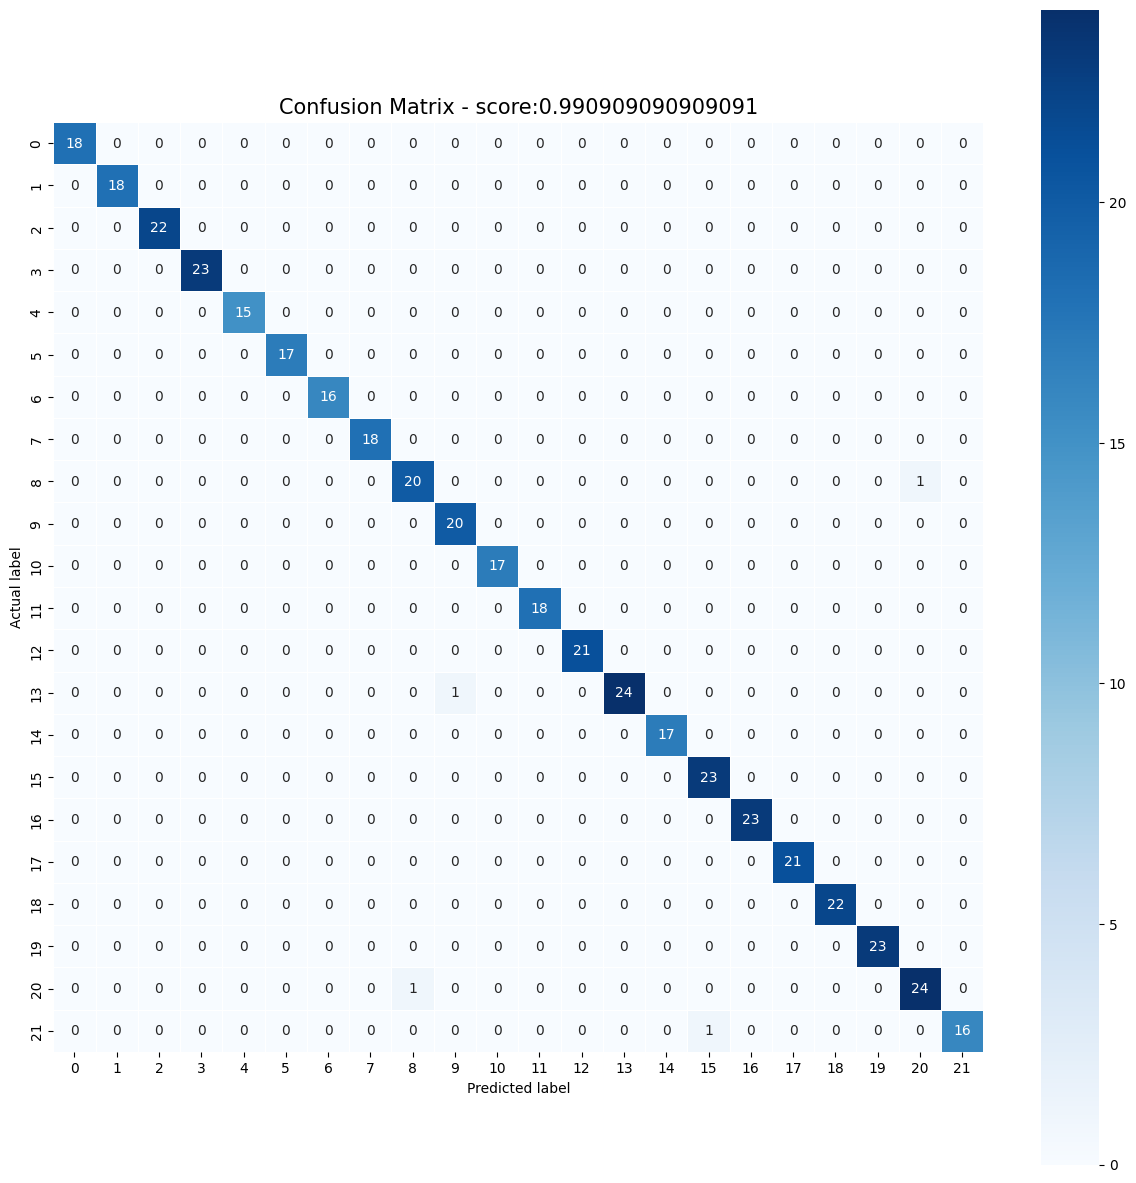

In [ ]:
# Generate the confusion matrix for Random Forest
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(15,15))

# Plot the confusion matrix using seaborn heatmap
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Confusion Matrix - score:'+str(accuracy_score(y_test,y_pred))
plt.title(all_sample_title, size = 15);
plt.show()

In [ ]:
# Print the classification report for Random Forest
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        18
   blackgram       1.00      1.00      1.00        22
    chickpea       1.00      1.00      1.00        23
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        16
      grapes       1.00      1.00      1.00        18
        jute       0.95      0.95      0.95        21
 kidneybeans       0.95      1.00      0.98        20
      lentil       1.00      1.00      1.00        17
       maize       1.00      1.00      1.00        18
       mango       1.00      1.00      1.00        21
   mothbeans       1.00      0.96      0.98        25
    mungbean       1.00      1.00      1.00        17
   muskmelon       0.96      1.00      0.98        23
      orange       1.00      1.00      1.00        23
      papaya       1.00    

## Xg boost

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder to convert categorical labels to numerical ones
le = LabelEncoder()

# Fit and transform the training labels, and transform the test labels
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [ ]:
from xgboost import XGBClassifier

# Initialize the XGBoost Classifier with specified parameters
# num_class is set to 22 as there are 22 unique crop labels
classifier_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softmax', # Objective for multi-class classification
    num_class=22,
    eval_metric='mlogloss', # Evaluation metric for multi-class logloss
    use_label_encoder=False, # Suppress warning for deprecated use_label_encoder
    random_state=42 # For reproducibility
)

In [ ]:
# Train the XGBoost model using the encoded training data
classifier_xgb.fit(X_train, y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, num_class=22, ...)

In [ ]:
# Make predictions on the test set using the trained XGBoost model (encoded labels)
y_pred_enc = classifier_xgb.predict(X_test)

In [ ]:
# Calculate and print the accuracy score for the XGBoost model
accuracy_xgb = accuracy_score(y_test_enc, y_pred_enc)
print('XGBoost Model accuracy score: {0:0.4f}'.format(accuracy_xgb))

# Append the accuracy and model name to the comparison lists
model.append('XGBoost')
acc.append(accuracy_xgb)

XGBoost Model accuracy score: 0.9977


In [ ]:
# Generate the confusion matrix using the encoded actual and predicted labels
cm = confusion_matrix(y_test_enc, y_pred_enc)

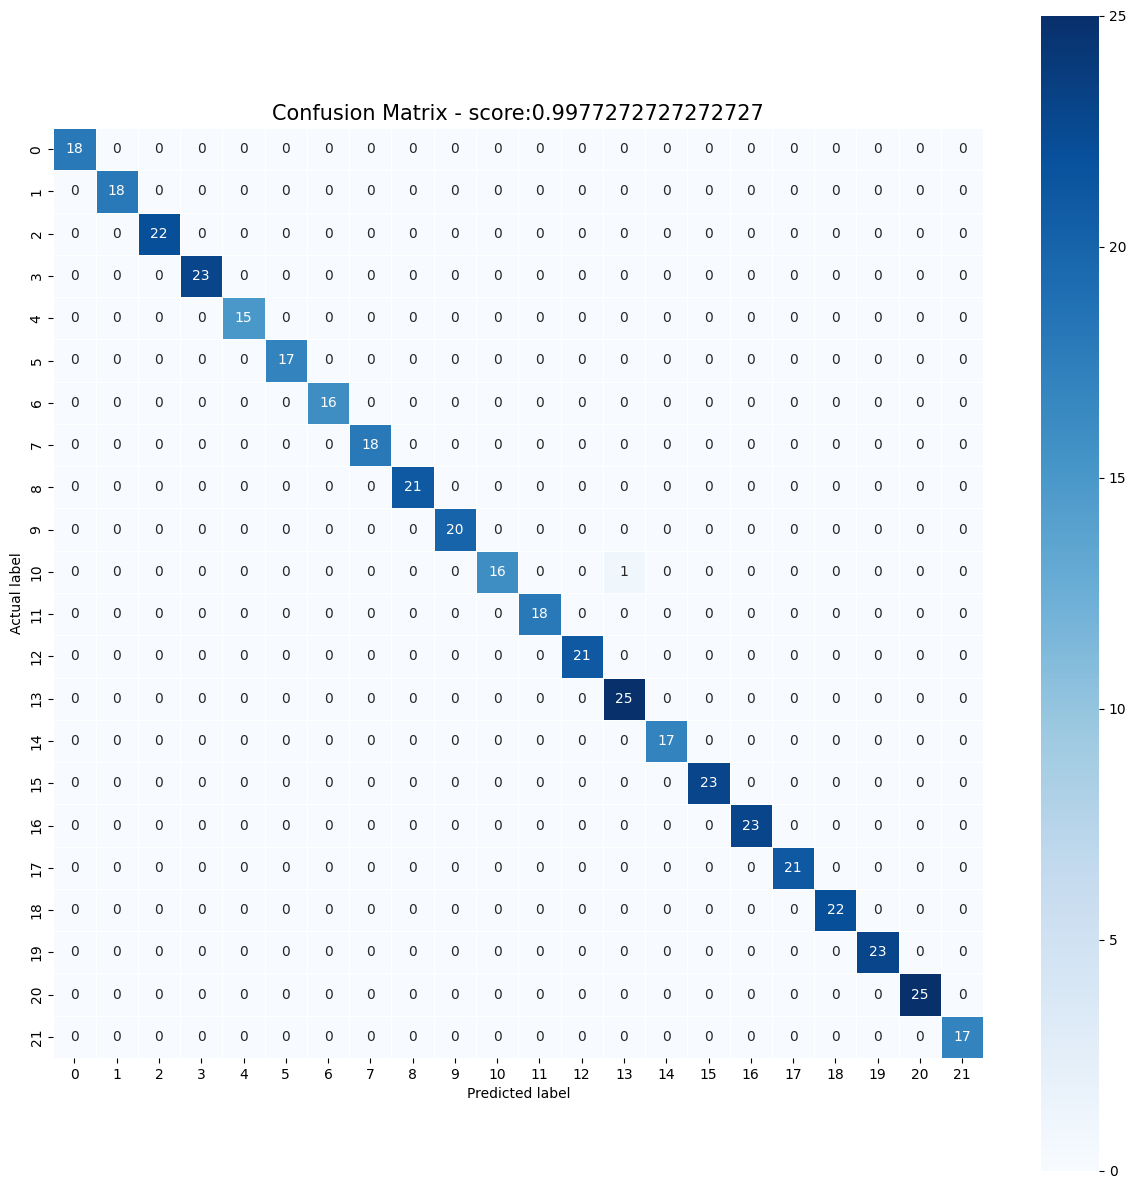

In [ ]:
# Plot the confusion matrix as a heatmap
plt.figure(figsize=(15,15))
sns.heatmap(
    cm,
    annot=True,
    fmt=".0f", # Format annotations as integers
    linewidths=.5,
    square=True,
    cmap='Blues'
)

plt.ylabel('Actual label')
plt.xlabel('Predicted label')
# Add title with the accuracy score
plt.title('Confusion Matrix - score:' + str(accuracy_xgb), size=15)
plt.show()

In [ ]:
# Inverse transform the encoded predictions back to original crop labels
y_pred_labels = le.inverse_transform(y_pred_enc)

# Display the first 10 predicted labels
print("First 10 Predicted Labels:")
print(y_pred_labels[:10])

# Inverse transform the encoded true test labels for the classification report
y_test_labels = le.inverse_transform(y_test_enc)

# Print the classification report for XGBoost
print("\nClassification Report for XGBoost:")
print(classification_report(y_test_labels, y_pred_labels))

First 10 Predicted Labels:
['watermelon' 'watermelon' 'grapes' 'chickpea' 'blackgram' 'rice'
 'mothbeans' 'kidneybeans' 'muskmelon' 'banana']

Classification Report for XGBoost:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        18
   blackgram       1.00      1.00      1.00        22
    chickpea       1.00      1.00      1.00        23
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        16
      grapes       1.00      1.00      1.00        18
        jute       1.00      1.00      1.00        21
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.94      0.97        17
       maize       1.00      1.00      1.00        18
       mango       1.00      1.00      1.00        21
   mothbeans       0.96      1.00      0.98        25
    mungbea

## comparison dataframe



Model Comparison:
                  Model  Accuracy
0  Logistic Regression  0.995455
1  Logistic Regression  0.968182
2        Decision Tree  0.990909
3                   DT  0.993182
4        Random Forest  0.990909
5              XGBoost  0.997727


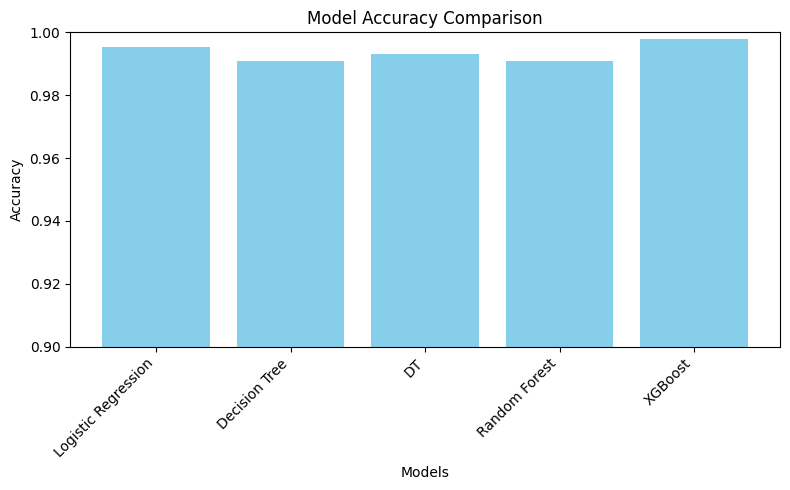

In [ ]:
# Create a comparison dataframe from the collected model names and accuracies
results = pd.DataFrame({
    'Model': model,
    'Accuracy': acc
})

print("\nModel Comparison:\n", results)

plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['Accuracy'], color='skyblue')
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0.9, 1.0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import pickle
# Define the filename for saving the Random Forest model
crop_rec_filename = 'crop_recomen.pickle'
# Save the trained Random Forest model (classifier_rf) to a pickle file
with open(crop_rec_filename,'wb') as file:
    pickle.dump(classifier_rf, file)

In [ ]:
import pickle
# Load the saved model from the pickle file
loaded_model = pickle.load(open(crop_rec_filename, 'rb'))
# Evaluate the loaded model's performance on the test set
result = loaded_model.score(X_test, y_test)
print(f"Accuracy of the loaded model: {result}")

Accuracy of the loaded model: 0.990909090909091


In [ ]:
# Display the first 2 rows of the original DataFrame for reference
df.head(2)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice


In [ ]:
# Make a prediction using the loaded model with a sample input
# The input features are N, P, K, temperature, humidity, ph, rainfall
print("Prediction for sample input [90, 40, 45, 20, 80, 7, 200]:")
print(loaded_model.predict([[90,40, 45, 20,80, 7, 200]]))

Prediction for sample input [90, 40, 45, 20, 80, 7, 200]:
['rice']
